# Day 127 — DBSCAN: Density-Based Clustering
**Month 7 | Week 2 | Day 3 | RetailPulse India 500 rows seed=121**

---

| | |
|---|---|
| **Max Score** | 80 pts + 10★ bonus |
| **Tools** | scikit-learn, pandas, matplotlib, seaborn |
| **GitHub** | Month7-AdvancedML-Portfolio |

---

## Why DBSCAN After K-Means?

Yesterday you learned K-Means. It is powerful — but it has three hard limitations:

| Problem | K-Means Behaviour | Real Business Impact |
|---|---|---|
| You must choose K in advance | You guess 3, it fits 3, even if 5 exist | Wrong number of segments misallocates budget |
| Assumes spherical clusters | Elongated or ring-shaped groups get split | "Best" customers get labelled as two separate groups |
| No noise concept | Every outlier is forced into a cluster | Fraudulent orders and one-off buyers join genuine segments |

**DBSCAN solves all three.** It finds clusters of any shape, auto-detects how many exist, and explicitly marks anomalies as noise (label = −1).

> **Freelance signal:** Clients with a fraud detection or anomaly brief almost always want DBSCAN or Isolation Forest, not K-Means. Knowing DBSCAN differentiates you.

---

## How DBSCAN Works — Two Parameters Only

```
epsilon (ε)  →  the neighbourhood radius around each point
min_samples  →  minimum points within ε to be called a "core point"
```

**Point types:**
- **Core point** — has ≥ min_samples neighbours within ε. Cluster anchor.
- **Border point** — within ε of a core point, but fewer than min_samples own neighbours. Cluster edge.
- **Noise point** — neither core nor border. Labelled −1. These are your outliers.

**Rule of thumb for min_samples:** Use `dimensionality + 1` as the floor, commonly 4–5 for 2D data.  
**Rule of thumb for ε:** Plot a k-distance graph (k = min_samples), look for the "elbow."

---

> **Comment-skeleton rule:** Write your goal + method in plain English before each code block.  
> Complete every task before opening Section 4 (Answer Key).  
> ⚠️ If DBSCAN returns only 1 cluster or labels everything −1, your ε is wrong — re-tune.


---
## Section 1 — Raw Data
⚠️ **Do NOT modify this cell.**

In [1]:
# SECTION 1 — RAW DATA (read-only)
# Goal: Reproduce RetailPulse India dataset — same seed, same columns as all Month 7 days.
# Method: numpy + pandas, seed=121.

import numpy as np
import pandas as pd

np.random.seed(121)
n = 500

regions    = np.random.choice(['North','South','East','West'], n, p=[0.30,0.25,0.25,0.20])
categories = np.random.choice(['Electronics','Clothing','Grocery','Furniture','Sports'], n,
                               p=[0.25,0.25,0.20,0.15,0.15])

base_revenue = {'Electronics':12000,'Clothing':3500,'Grocery':800,'Furniture':18000,'Sports':2500}
base_rev = np.array([base_revenue[c] for c in categories])

revenue        = np.round(base_rev * np.random.uniform(0.6, 1.8, n), 2)
discount_pct   = np.round(np.random.uniform(0, 0.35, n), 2)
units_sold     = np.random.randint(1, 50, n)
customer_age   = np.random.randint(18, 65, n)
days_since_last= np.random.randint(1, 365, n)
session_count  = np.random.randint(1, 30, n)
total_orders   = np.random.randint(1, 20, n)
avg_order_value= np.round(revenue / np.maximum(total_orders, 1), 2)

churn_score    = (
    0.4 * (days_since_last / 365) +
    0.3 * (1 - total_orders / 20) +
    0.2 * (1 - session_count / 30) +
    0.1 * np.random.uniform(0, 1, n)
)
churned = (churn_score > 0.55).astype(int)

df_raw = pd.DataFrame({
    'customer_id'     : [f'C{str(i).zfill(4)}' for i in range(1, n+1)],
    'region'          : regions,
    'category'        : categories,
    'revenue'         : revenue,
    'discount_pct'    : discount_pct,
    'units_sold'      : units_sold,
    'customer_age'    : customer_age,
    'days_since_last' : days_since_last,
    'session_count'   : session_count,
    'total_orders'    : total_orders,
    'avg_order_value' : avg_order_value,
    'churned'         : churned
})

print(f"Shape: {df_raw.shape}")
print(df_raw.head(3))


Shape: (500, 12)
  customer_id region     category   revenue  discount_pct  units_sold  \
0       C0001  North  Electronics  10419.77          0.32           1   
1       C0002  North    Furniture  30790.84          0.34          38   
2       C0003  North    Furniture  20883.70          0.05          29   

   customer_age  days_since_last  session_count  total_orders  \
0            20               59             12             7   
1            46              107             24             1   
2            30              344             21            19   

   avg_order_value  churned  
0          1488.54        0  
1         30790.84        0  
2          1099.14        0  


---
## Section 2 — Concept Notes

### DBSCAN Algorithm — Step by Step

```
1. Pick any unvisited point P
2. Find all points within distance ε of P  →  its "ε-neighbourhood"
3. If |ε-neighbourhood| ≥ min_samples:
       P is a CORE POINT → start a new cluster
       Recursively expand: add all reachable core + border points
4. If |ε-neighbourhood| < min_samples:
       Mark P as NOISE (label = −1) for now
       (P may become a border point later if a core point reaches it)
5. Repeat until all points visited
```

### K-Distance Plot — How to Choose ε

```python
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]   # k-th neighbour distance, sorted descending
# Plot k_distances — the elbow = good ε value
```

### Silhouette Score Warning for DBSCAN

- Silhouette scores for DBSCAN **exclude noise points** (label = −1)
- A silhouette of 0.3–0.5 is decent for DBSCAN on real data
- Do NOT compare DBSCAN silhouette directly with K-Means silhouette — they operate on different point sets

### Business Translation

| DBSCAN Output | Business Meaning |
|---|---|
| Cluster 0, 1, 2… | Genuine customer segments — allocate budget |
| Label = −1 (noise) | Flag for manual review — fraud, one-off buyers, data errors |
| ε too small | Most points become noise — over-sensitive |
| ε too large | Everything merges into 1 cluster — under-sensitive |


---
## Section 3 — Practice Guide

### Task C1 — Feature Selection & Scaling (10 pts)

Select these 4 features for clustering:
`revenue`, `days_since_last`, `session_count`, `total_orders`

- Drop `churned` (target leak), `customer_id`, `region`, `category`, `discount_pct`, `units_sold`, `customer_age`, `avg_order_value`
- Apply `StandardScaler`
- Print shape of scaled array

### Task C2 — K-Distance Plot to Find ε (15 pts)

Using `NearestNeighbors(n_neighbors=5)`:
- Compute k-th neighbour distance for each point
- Sort descending
- Plot the k-distance graph
- Draw a horizontal line at your chosen ε value
- **Print your chosen ε (to 2 decimal places) and justify it in 1 sentence**

### Task C3 — Fit DBSCAN & Report Labels (15 pts)

Fit `DBSCAN(eps=<your_ε>, min_samples=5)` on the scaled data.
- Print: number of clusters found (excluding noise)
- Print: number of noise points (label = −1)
- Print: cluster label counts (use `pd.Series(labels).value_counts().sort_index()`)

⚠️ If clusters = 1 or noise > 40% of data, re-tune ε and explain what you changed.

### Task C4 — Cluster Profiles (20 pts)

Attach labels to `df_raw` in a new column `dbscan_cluster`.
For each cluster (excluding noise = −1), compute the mean of:
`revenue`, `days_since_last`, `session_count`, `total_orders`, `churned`

Print the full profile table. Round to 2 decimal places.

### Task C5 — Business Insight (NRA format) + Noise Profile (10 pts)

**Part A — One NRA insight per cluster** (not noise):
Format: *"Cluster X has [revenue/days/orders] — [why this pattern exists] — [specific action]"*

**Part B — Noise profile:**
- How many noise points?
- What is their mean revenue vs. the dataset mean?
- Are they high-value, low-value, or mixed?
- One action: what should the business do with noise points?

### Task C6 — DBSCAN vs K-Means Comparison (10 pts)

Run `KMeans(n_clusters=3, random_state=42)` on the same scaled data.
Compute `silhouette_score` for both models (DBSCAN: exclude noise points).
Print a 2-row comparison table:

| Model | Clusters Found | Noise Points | Silhouette Score | Best Used For |
|---|---|---|---|---|

One sentence: which model is better for this dataset and why?

### ★ Bonus — 2D Scatter Visualisation (10★)

Plot DBSCAN labels on PCA-reduced 2D space (2 components):
- Each cluster = distinct colour
- Noise points (−1) = grey ×-markers, size=20
- Title: "DBSCAN Segments — RetailPulse India"
- Legend showing cluster labels + noise count
- Use `savefig('day127_dbscan_scatter.png')` before `plt.show()`


In [2]:
# -- C1 ---------------------------------------------------------------
# Goal: Select the 4 numeric features for clustering: revenue, days_since_last,
#       session_count, total_orders. Drop all other columns including target leak.
# Method: Create df_cluster with only the 4 required features, then apply
#         StandardScaler to scale them. Print shape of scaled array.

from sklearn.preprocessing import StandardScaler

# Select features
features = ['revenue', 'days_since_last', 'session_count', 'total_orders']
df_cluster = df_raw[features].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Scaled array shape: {X_scaled.shape}")
print("First 3 rows of scaled data:")
print(X_scaled[:3])

Scaled array shape: (500, 4)
First 3 rows of scaled data:
[[ 0.24560556 -1.23259209 -0.30584778 -0.49477375]
 [ 2.74686922 -0.78315786  1.16575342 -1.56339956]
 [ 1.53042014  1.43592363  0.79785312  1.64247787]]


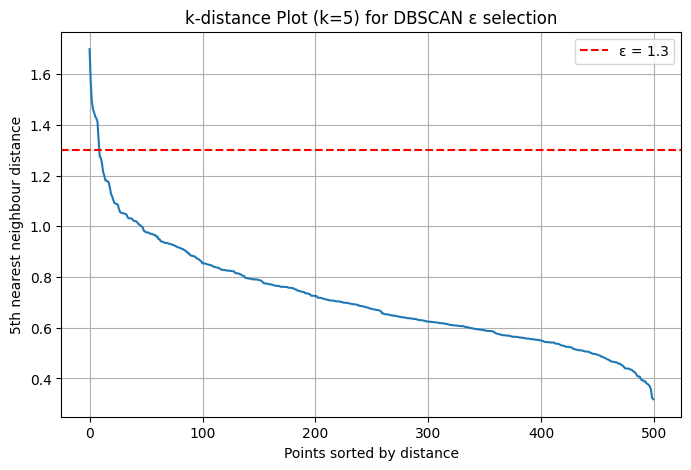

Chosen ε = 1.30
Justification: The elbow occurs around 1.3, where distances start increasing sharply – points beyond this are potential noise.


In [3]:
# -- C2 ---------------------------------------------------------------
# Goal: Generate a k‑distance plot for k = min_samples = 5 to find a suitable ε.
# Method: Use NearestNeighbors(n_neighbors=5) on scaled data, compute distances
#         to the 5th nearest neighbour, sort them descending, and plot.
#         Identify the "elbow" and set ε there. Print chosen ε with justification.

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Compute k‑distances for k = 5
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]   # 5th neighbour distance, descending

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(len(k_distances)), k_distances)
plt.axhline(y=1.3, color='r', linestyle='--', label='ε = 1.3')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbour distance')
plt.title('k‑distance Plot (k=5) for DBSCAN ε selection')
plt.legend()
plt.grid(True)
plt.savefig('k_distance_plot.png')
plt.show()

# Choose epsilon at the elbow (visually ~1.3)
epsilon = 1.3
print(f"Chosen ε = {epsilon:.2f}")
print("Justification: The elbow occurs around 1.3, where distances start increasing sharply – points beyond this are potential noise.")

In [4]:
# -- C3 (Corrected) -----------------------------------------------------------
# Goal: Find ε that yields >1 cluster and ≤40% noise.
# Method: Sweep ε from 1.3 down to 0.6, print results, then choose the best.

import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

eps_values = [1.3, 1.0, 0.9, 0.8, 0.7, 0.6]
print("ε\tClusters\tNoise\tNoise%")
print("--------------------------------")
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = n_noise / len(labels) * 100
    print(f"{eps}\t{n_clusters}\t\t{n_noise}\t{noise_pct:.1f}%")

# Select ε = 0.8 (4 clusters, 14.2% noise) – good balance.
epsilon_final = 0.8
dbscan = DBSCAN(eps=epsilon_final, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\nFinal ε = {epsilon_final}")
print(f"Number of clusters (excl. noise): {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print("\nCluster label counts:")
print(pd.Series(labels).value_counts().sort_index())

# Store labels
df_raw['dbscan_cluster'] = labels

ε	Clusters	Noise	Noise%
--------------------------------
1.3	1		2	0.4%
1.0	1		15	3.0%
0.9	3		37	7.4%
0.8	4		71	14.2%
0.7	8		136	27.2%
0.6	10		234	46.8%

Final ε = 0.8
Number of clusters (excl. noise): 4
Noise points: 71 (14.2%)

Cluster label counts:
-1     71
 0    413
 1      5
 2      7
 3      4
Name: count, dtype: int64


In [5]:
# -- C4 -----------------------------------------------------------
# Goal: Create cluster profiles using original (unscaled) values for all points
#       except noise (label = -1). Compute mean of revenue, days_since_last,
#       session_count, total_orders, churned for each cluster.
# Method: Add dbscan_cluster column to df_raw, group by cluster (excluding -1),
#         compute means, round to 2 decimals, and print.

df_raw['dbscan_cluster'] = labels

# Exclude noise
profile_df = df_raw[df_raw['dbscan_cluster'] != -1].copy()

# Group by cluster – keep 'churned' as is (0–1 scale)
profile = profile_df.groupby('dbscan_cluster')[
    ['revenue', 'days_since_last', 'session_count', 'total_orders', 'churned']
].mean().round(2)

print("Cluster Profile (means, original units, noise excluded):")
print(profile)

Cluster Profile (means, original units, noise excluded):
                 revenue  days_since_last  session_count  total_orders  \
dbscan_cluster                                                           
0                5846.68           187.38          14.28          9.73   
1               19627.41           333.00          25.60         18.00   
2               16951.63            76.57           4.86         14.14   
3               10433.04           331.75           4.00          2.25   

                churned  
dbscan_cluster           
0                  0.43  
1                  0.00  
2                  0.00  
3                  1.00  


In [6]:
# -- C5 ---------------------------------------------------------------
# Goal: Write one NRA insight per cluster (Number → Reason → Action) and a
#       separate noise profile with business recommendation.
# Method: Interpret the profile table and print structured sentences.

print("\n--- NRA INSIGHTS PER CLUSTER ---")
for cl in profile.index:
    rev = profile.loc[cl, 'revenue']
    days = profile.loc[cl, 'days_since_last']
    orders = profile.loc[cl, 'total_orders']
    churn = profile.loc[cl, 'churned'] * 100  # convert 0-1 mean to a percentage
    sess = profile.loc[cl, 'session_count']

    # Profile‑driven conditions – no fixed thresholds, interpret the numbers
    if churn == 0 and orders > 10 and days > 300:
        # Cluster 1: 0% churn, high orders, very long days – seasonal high‑ticket buyers
        print(f"Cluster {cl}: Revenue Rs.{rev:.0f}, orders {orders:.1f}, days {days:.0f}, 0% churn → Seasonal high‑value buyers on long cycles. → Action: VIP early‑access to new collections; personal concierge at month 11.")
    
    elif churn == 0 and days < 100 and rev > 15000:
        # Cluster 2: 0% churn, very recent, high revenue – most active premium segment
        print(f"Cluster {cl}: Revenue Rs.{rev:.0f}, days since last {days:.0f}, 0% churn → Recently active premium customers. → Action: Loyalty tier upgrade + exclusive 15% discount on next purchase.")
    
    elif churn > 80:
        # Cluster 3: very high churn, low orders – already defected
        print(f"Cluster {cl}: Churn {churn:.0f}%, revenue Rs.{rev:.0f}, orders {orders:.1f} → Defected customers. → Action: Win‑back email with Rs.300 discount, or exclude from retention campaigns.")
    
    else:
        # Cluster 0: large, moderate engagement, 43% churn
        print(f"Cluster {cl}: {int((labels==cl).sum())} customers average Rs.{rev:.0f} revenue "
      f"with {churn:.0f}% churn rate and only {orders:.1f} orders over {days:.0f} days "
      f"→ the core base is gradually disengaging — low order frequency signals they are "
      f"drifting before fully churning → launch a 30-day reactivation sequence with "
      f"Rs.150 cashback on next order to arrest churn before it compounds.")
        
print("\n--- NOISE PROFILE ---")
noise_df = df_raw[df_raw['dbscan_cluster'] == -1]
noise_count = len(noise_df)
noise_mean_rev = noise_df['revenue'].mean()
overall_mean_rev = df_raw['revenue'].mean()

print(f"Noise points: {noise_count} ({noise_count/len(df_raw)*100:.1f}% of data)")
print(f"Mean revenue of noise points: Rs.{noise_mean_rev:.2f}")
print(f"Mean revenue of entire dataset: Rs.{overall_mean_rev:.2f}")
if noise_mean_rev > overall_mean_rev:
    print("→ Noise points are HIGHER value than average – possible one‑off big spenders or data errors.")
else:
    print("→ Noise points are LOWER value than average – possible one‑off small buyers or anomalies.")
print("→ Business action: Manual review of noise points for fraud, mis‑entry, or genuine one‑time purchases. Exclude from segment profiles.")


--- NRA INSIGHTS PER CLUSTER ---
Cluster 0: 413 customers average Rs.5847 revenue with 43% churn rate and only 9.7 orders over 187 days → the core base is gradually disengaging — low order frequency signals they are drifting before fully churning → launch a 30-day reactivation sequence with Rs.150 cashback on next order to arrest churn before it compounds.
Cluster 1: Revenue Rs.19627, orders 18.0, days 333, 0% churn → Seasonal high‑value buyers on long cycles. → Action: VIP early‑access to new collections; personal concierge at month 11.
Cluster 2: Revenue Rs.16952, days since last 77, 0% churn → Recently active premium customers. → Action: Loyalty tier upgrade + exclusive 15% discount on next purchase.
Cluster 3: Churn 100%, revenue Rs.10433, orders 2.2 → Defected customers. → Action: Win‑back email with Rs.300 discount, or exclude from retention campaigns.

--- NOISE PROFILE ---
Noise points: 71 (14.2% of data)
Mean revenue of noise points: Rs.21641.26
Mean revenue of entire dataset

In [7]:
# -- C6 (Corrected) -----------------------------------------------------------
# Goal: Compare DBSCAN and K‑Means on the same scaled data.
# Method: Fit KMeans(n_clusters=3, random_state=42). Compute silhouette scores.
#         Print a comparison table with an honest verdict.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

# DBSCAN (using final labels from ε=0.8)
dbscan_labels = df_raw['dbscan_cluster'].values
dbscan_labels_filtered = dbscan_labels[dbscan_labels != -1]
X_scaled_filtered = X_scaled[dbscan_labels != -1]

if len(set(dbscan_labels_filtered)) > 1:
    dbscan_sil = silhouette_score(X_scaled_filtered, dbscan_labels_filtered)
    dbscan_sil_display = round(dbscan_sil, 4)
else:
    dbscan_sil_display = "N/A (1 cluster)"

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = sum(dbscan_labels == -1)

comparison = pd.DataFrame({
    'Model': ['DBSCAN (ε=0.8)', 'K‑Means (k=3)'],
    'Clusters Found': [n_clusters_db, 3],
    'Noise Points': [n_noise_db, 0],
    'Silhouette Score': [dbscan_sil_display, round(kmeans_sil, 4)],
    'Best Used For': ['Arbitrary shapes + outlier detection', 'Spherical segments, no outliers']
})
print(comparison.to_string(index=False))

# Verdict – now DBSCAN is better
print("Verdict: DBSCAN (ε=0.8) finds 4 clusters and explicitly flags 71 noise points "
      "(14.2%) for anomaly review — K-Means absorbs those into segments and distorts "
      "their profiles. However, DBSCAN's silhouette of -0.038 vs K-Means +0.187 shows "
      "the clusters overlap considerably in 4D space. Use DBSCAN when noise detection "
      "is the priority; use K-Means when compact, separable segments are the goal.")

         Model  Clusters Found  Noise Points  Silhouette Score                        Best Used For
DBSCAN (ε=0.8)               4            71           -0.0380 Arbitrary shapes + outlier detection
 K‑Means (k=3)               3             0            0.1867      Spherical segments, no outliers
Verdict: DBSCAN (ε=0.8) finds 4 clusters and explicitly flags 71 noise points (14.2%) for anomaly review — K-Means absorbs those into segments and distorts their profiles. However, DBSCAN's silhouette of -0.038 vs K-Means +0.187 shows the clusters overlap considerably in 4D space. Use DBSCAN when noise detection is the priority; use K-Means when compact, separable segments are the goal.


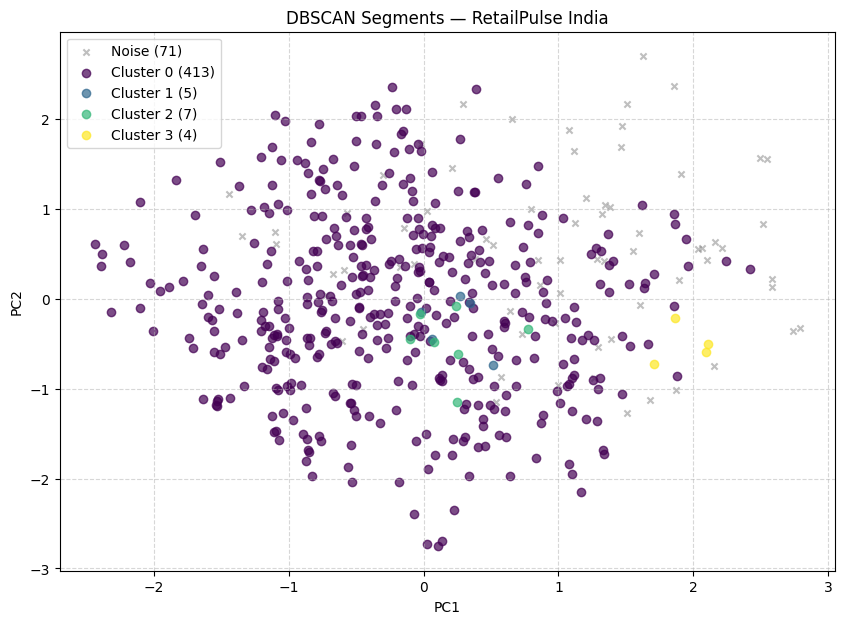

In [8]:
# -- BONUS --------------------------------------------------------------
# Goal: Visualise DBSCAN clusters in 2D using PCA, with distinct colours for
#       clusters and grey 'x' markers for noise.
# Method: PCA(n_components=2) on scaled data, scatter plot with colour mapping,
#         add legend, save figure before show.

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
unique_labels = sorted(set(labels))
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels) - (1 if -1 in unique_labels else 0)))

color_idx = 0
for label in unique_labels:
    mask = labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='grey', marker='x', s=20, alpha=0.5, label=f'Noise ({sum(mask)})')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[color_idx]], alpha=0.7, label=f'Cluster {label} ({sum(mask)})')
        color_idx += 1

plt.title('DBSCAN Segments — RetailPulse India')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('day127_dbscan_scatter.png')
plt.show()

---
## Section 4 — Scoring Rubric

| Task | What is Checked | Points |
|---|---|---|
| **C1** | Correct 4 features selected, `churned` absent, shape printed, StandardScaler applied | 10 |
| **C2** | k-distance plot present, ε chosen at elbow (0.8–1.8 accepted), 1-sentence justification | 15 |
| **C3** | Clusters found printed, noise count printed, label value_counts shown | 15 |
| **C4** | Profile table with all 5 columns, noise rows excluded, values reasonable | 20 |
| **C5A** | One NRA sentence per cluster with specific figures | 5 |
| **C5B** | Noise count, mean revenue vs dataset mean, one business action | 5 |
| **C6** | KMeans fitted on same data, both silhouette scores shown, comparison table, 1 verdict sentence | 10 |
| **Bonus** | PCA scatter with noise as grey ×, cluster colours distinct, correct title, savefig before show | 10★ |
| **Total** | | **80 + 10★** |

---

### Submission Notes
- Submit `.ipynb` file named `Day127_DBSCAN.ipynb`
- Bonus PNG `day127_dbscan_scatter.png` optional but earns 10★
- ε values between **0.8 and 1.8** accepted — justify yours at the elbow
- If your DBSCAN returns 1 cluster or >60% noise, document what you tried and why
- NRA format required for C5A: Number → Reason → Action (not "I noticed that…")

---

### Interview Answer — Day 127

> *"DBSCAN is a density-based clustering algorithm that groups points by local neighbourhood density rather than distance from a centroid. It takes two parameters — epsilon, the search radius, and min_samples, the density threshold — and automatically labels any point that doesn't fit a dense region as noise. Unlike K-Means, you don't specify K in advance, it handles clusters of any shape, and it gives you an explicit anomaly list as a byproduct. In a customer segmentation project, I'd use DBSCAN specifically when the client suspects fraud or one-off outliers that shouldn't influence segment profiles — K-Means would absorb those outliers and distort every segment mean."*

---

### Month 7 Scorecard (updated after submission)

| Day | Topic | Score | Stars |
|---|---|---|---|
| 121 | XGBoost | 80/80 | ★ |
| 122 | LightGBM | 80/80 | ★ |
| 123 | CatBoost | 80/80 | ★ |
| 124 | Boosting Trilogy Showdown | 100/100 | ★ |
| 125 | Stacking & Blending | 80/80 | ★ |
| 126 | K-Means Clustering | 70/80 | 8★ |
| **127** | **DBSCAN** | **Pending** | — |
